In [ ]:
import pandas as pd

# 1. Base Sheet ID and the exact GID from your URL
sheet_id = "1BFhDfOQzLxt0BiS1daLIifn_kBwMv-H6lDTG84k2uII"
gid = "422339371"

# 2. Build the direct export link targeting this specific tab
export_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# 3. Read the data directly into a pandas DataFrame named df
df = pd.read_csv(export_url)

# 4. Display the first 5 rows to confirm it loaded the correct tab
df.head()

,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit,Order_ID,Order_status,Month,Year,Segment,Order_Value_Category
0,01/06/26,C001,Laptop,Electronics,Delhi,1,"₹65,000.00","₹8,000.00",1001,Completed,June,2026,New Customer,Medium Value
1,03/06/26,C002,Phone,Electronics,Delhi,2,"₹50,000.00","₹6,000.00",1002,Completed,June,2026,Repeat Customer,Medium Value
2,01/02/26,C003,Headphones,Electronics,Mumbai,1,"₹5,000.00","₹1,200.00",1003,Completed,February,2026,Repeat Customer,Low Value
3,05/06/26,C004,Chair,Furniture,Bangalore,3,"₹12,000.00","₹2,500.00",1004,Completed,June,2026,Repeat Customer,Low Value
4,03/07/26,C314,Vacuum Cleaner,Home,Delhi,1,"₹8,506.00","₹1,455.00",1005,Completed,July,2026,Repeat Customer,Low Value


In [ ]:
import pandas as pd

# 1. Place your Google Sheet URL here
sheet_url = "https://docs.google.com/spreadsheets/d/1jh8UeSiUokzElxnSYRbD1JAgN-Wqkk4Sqp9axEvNDbw/edit?usp=sharing"

# 2. Convert the viewing URL to a direct CSV export URL
export_url = sheet_url.replace('/edit?usp=sharing', '/export?format=csv')

# 3. Read the data directly into a pandas DataFrame named df
df = pd.read_csv(export_url)

# 4. Display the first 5 rows to confirm it worked
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
0,1001,01-06-2026,C001,Laptop,Electronics,Delhi,1.0,65000,8000.0
1,1002,03-06-2026,C002,Phone,Electronics,Delhi,2.0,â‚¹50000,6000.0
2,1003,31-02-2026,C003,Headphones,electronics,Mumbai,1.0,5000,1200.0
3,1004,05-06-2026,C004,Chair,Furniture,Bangalore,-3.0,12000,2500.0
4,1005,03-07-2026,C314,Vacuum Cleaner,Home,Delhi,NaN,8506,1455.0


In [ ]:
import pandas as pd

# 1. Number of rows and 2. Number of columns
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

print("\n" + "="*40 + "\n")

# 3. Column names and 4. Data types
print("--- Column Names & Data Types ---")
print(df.dtypes)

print("\n" + "="*40 + "\n")

# 5. Summary statistics (includes numeric and text columns)
print("--- Summary Statistics ---")
print(df.describe(include='all'))

print("\n" + "="*40 + "\n")

# 6. Unique values in categorical columns
print("--- Unique Values in Categorical Columns ---")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())

print("\n" + "="*40 + "\n")

# 7. First 5 rows
print("--- First 5 Rows ---")
display(df.head())

Number of rows: 2000
Number of columns: 9


--- Column Names & Data Types ---
Order_ID         int64
Order_Date      object
Customer_ID     object
Product         object
Category        object
Region          object
Quantity       float64
Revenue         object
Profit         float64
dtype: object


--- Summary Statistics ---
           Order_ID  Order_Date Customer_ID  Product     Category   Region  \
count   2000.000000        2000        1974     1993         2000     2000   
unique          NaN         240         415       24           15        8   
top             NaN  08-03-2026        C476  Perfume  Electronics  Chennai   
freq            NaN          17          45      106          500      302   
mean    1988.741000         NaN         NaN      NaN          NaN      NaN   
std      570.083494         NaN         NaN      NaN          NaN      NaN   
min     1001.000000         NaN         NaN      NaN          NaN      NaN   
25%     1494.750000         NaN         NaN     

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
0,1001,01-06-2026,C001,Laptop,Electronics,Delhi,1.0,65000,8000.0
1,1002,03-06-2026,C002,Phone,Electronics,Delhi,2.0,â‚¹50000,6000.0
2,1003,31-02-2026,C003,Headphones,electronics,Mumbai,1.0,5000,1200.0
3,1004,05-06-2026,C004,Chair,Furniture,Bangalore,-3.0,12000,2500.0
4,1005,03-07-2026,C314,Vacuum Cleaner,Home,Delhi,NaN,8506,1455.0


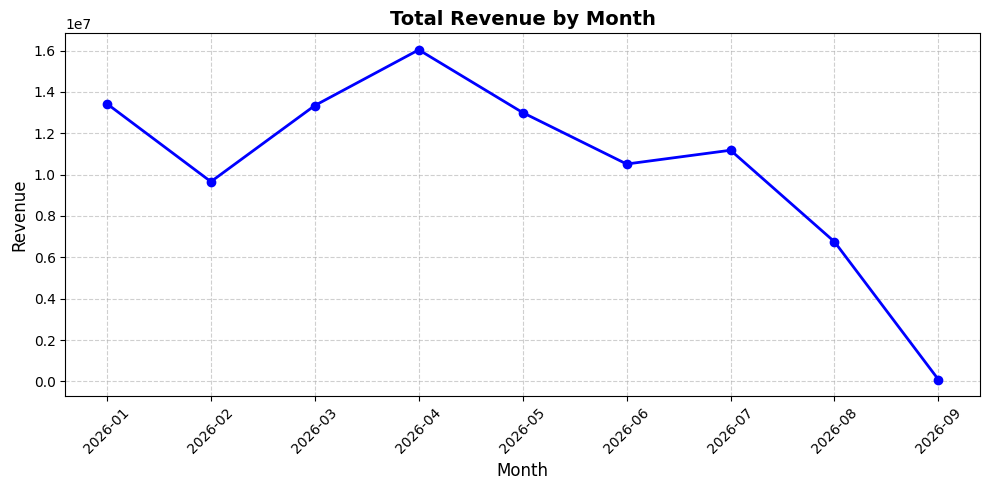

Highest Revenue Month: 2026-04 (₹16,038,284.00)
Lowest Revenue Month:  2026-09 (₹86,165.00)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Base Sheet ID and the exact GID for the 'Clean Data' tab
sheet_id = "1BFhDfOQzLxt0BiS1daLIifn_kBwMv-H6lDTG84k2uII"
gid = "422339371"

# 2. Direct CSV export link specifically for 'Clean Data'
export_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# 3. Read data directly into DataFrame df
df = pd.read_csv(export_url)

# 4. Clean Revenue column (removes ₹ symbol, commas, and spaces)
df['Revenue_Clean'] = (
    df['Revenue']
    .astype(str)
    .str.replace(r'[^\d.]', '', regex=True)
)
df['Revenue_Clean'] = pd.to_numeric(df['Revenue_Clean'], errors='coerce')

# 5. Convert Order_Date to datetime (handles DD/MM/YY format in Clean Data)
df['Order_Date_DT'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%y', errors='coerce')

# 6. Extract Year-Month period to keep months in chronological order
df['YearMonth'] = df['Order_Date_DT'].dt.to_period('M')

# 7. Group by month and calculate total Revenue
monthly_revenue = df.groupby('YearMonth')['Revenue_Clean'].sum().reset_index()

# Convert YearMonth to string label for plotting
monthly_revenue['Month_Label'] = monthly_revenue['YearMonth'].astype(str)

# 8. Create the line chart
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue['Month_Label'], monthly_revenue['Revenue_Clean'], marker='o', color='b', linewidth=2)

# Chart labels and title
plt.title('Total Revenue by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)

# Formatting adjustments
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

# Print highest and lowest revenue months
highest_row = monthly_revenue.loc[monthly_revenue['Revenue_Clean'].idxmax()]
lowest_row = monthly_revenue.loc[monthly_revenue['Revenue_Clean'].idxmin()]

print(f"Highest Revenue Month: {highest_row['Month_Label']} (₹{highest_row['Revenue_Clean']:,.2f})")
print(f"Lowest Revenue Month:  {lowest_row['Month_Label']} (₹{lowest_row['Revenue_Clean']:,.2f})")

In [ ]:
import pandas as pd

# 1. Base Sheet ID and the exact GID for the 'Clean Data' tab
sheet_id = "1BFhDfOQzLxt0BiS1daLIifn_kBwMv-H6lDTG84k2uII"
gid = "422339371"

# 2. Build direct CSV export link for the 'Clean Data' tab
export_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# 3. Read the data directly into a pandas DataFrame named df
df = pd.read_csv(export_url)

# 4. Display the first 5 rows to confirm
df.head()

,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit,Order_ID,Order_status,Month,Year,Segment,Order_Value_Category
0,01/06/26,C001,Laptop,Electronics,Delhi,1,"₹65,000.00","₹8,000.00",1001,Completed,June,2026,New Customer,Medium Value
1,03/06/26,C002,Phone,Electronics,Delhi,2,"₹50,000.00","₹6,000.00",1002,Completed,June,2026,Repeat Customer,Medium Value
2,01/02/26,C003,Headphones,Electronics,Mumbai,1,"₹5,000.00","₹1,200.00",1003,Completed,February,2026,Repeat Customer,Low Value
3,05/06/26,C004,Chair,Furniture,Bangalore,3,"₹12,000.00","₹2,500.00",1004,Completed,June,2026,Repeat Customer,Low Value
4,03/07/26,C314,Vacuum Cleaner,Home,Delhi,1,"₹8,506.00","₹1,455.00",1005,Completed,July,2026,Repeat Customer,Low Value


In [ ]:
import pandas as pd

# 1. Number of rows and 2. Number of columns
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

print("\n" + "="*40 + "\n")

# 3. Column names and 4. Data types
print("--- Column Names & Data Types ---")
print(df.dtypes)

print("\n" + "="*40 + "\n")

# 5. Summary statistics (includes numeric and text columns)
print("--- Summary Statistics ---")
print(df.describe(include='all'))

print("\n" + "="*40 + "\n")

# 6. Unique values in categorical columns
print("--- Unique Values in Categorical Columns ---")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())

print("\n" + "="*40 + "\n")

# 7. First 5 rows
print("--- First 5 Rows ---")
display(df.head())

Number of rows: 2000
Number of columns: 14


--- Column Names & Data Types ---
Order_Date              object
Customer_ID             object
Product                 object
Category                object
Region                  object
Quantity                 int64
Revenue                 object
Profit                  object
Order_ID                 int64
Order_status            object
Month                   object
Year                    object
Segment                 object
Order_Value_Category    object
dtype: object


--- Summary Statistics ---
       Order_Date Customer_ID  Product     Category  Region     Quantity  \
count        2000        2000     1993         2000    2000  2000.000000   
unique        238         415       24            7      13          NaN   
top      08/03/26        C476  Perfume  Electronics  Mumbai          NaN   
freq           17          45      106          554     305          NaN   
mean          NaN         NaN      NaN          NaN     NaN     

,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit,Order_ID,Order_status,Month,Year,Segment,Order_Value_Category
0,01/06/26,C001,Laptop,Electronics,Delhi,1,"₹65,000.00","₹8,000.00",1001,Completed,June,2026,New Customer,Medium Value
1,03/06/26,C002,Phone,Electronics,Delhi,2,"₹50,000.00","₹6,000.00",1002,Completed,June,2026,Repeat Customer,Medium Value
2,01/02/26,C003,Headphones,Electronics,Mumbai,1,"₹5,000.00","₹1,200.00",1003,Completed,February,2026,Repeat Customer,Low Value
3,05/06/26,C004,Chair,Furniture,Bangalore,3,"₹12,000.00","₹2,500.00",1004,Completed,June,2026,Repeat Customer,Low Value
4,03/07/26,C314,Vacuum Cleaner,Home,Delhi,1,"₹8,506.00","₹1,455.00",1005,Completed,July,2026,Repeat Customer,Low Value


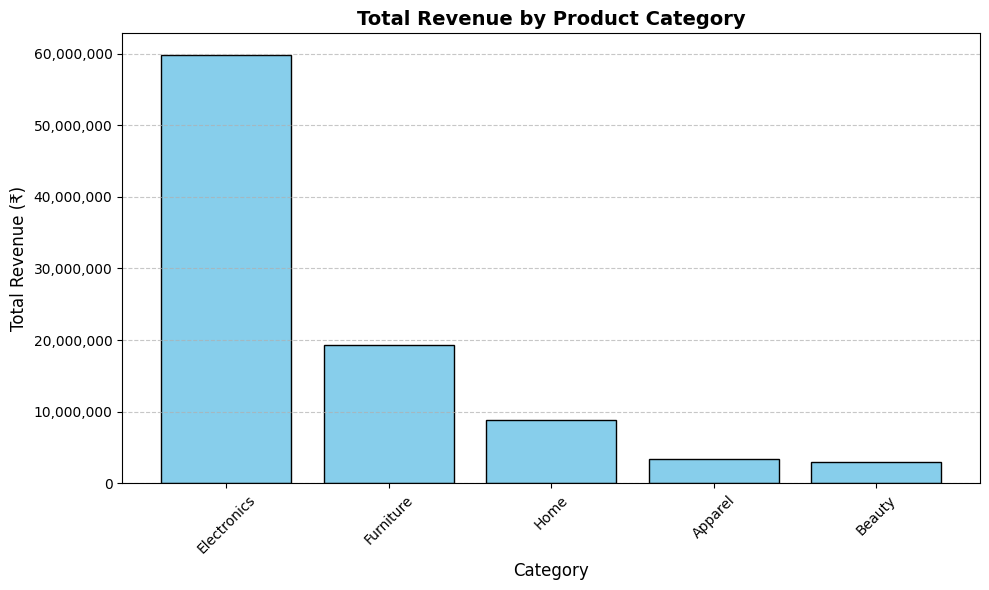

Highest Revenue Category: Electronics (₹59,837,525.00)
Lowest Revenue Category:  Beauty (₹2,942,829.00)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean Category column (converts text to Title Case so casing variations group together)
df['Category_Clean'] = df['Category'].astype(str).str.strip().str.title()

# 2. Clean Revenue column (removes ₹ symbol, commas, spaces) and convert to numeric
df['Revenue_Clean'] = (
    df['Revenue']
    .astype(str)
    .str.replace(r'[^\d.]', '', regex=True)
)
df['Revenue_Clean'] = pd.to_numeric(df['Revenue_Clean'], errors='coerce')

# 3. Group by Category, calculate total Revenue, and sort from highest to lowest
category_revenue = (
    df.groupby('Category_Clean')['Revenue_Clean']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 4. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(category_revenue['Category_Clean'], category_revenue['Revenue_Clean'], color='skyblue', edgecolor='black')

# 5. Add a clear title
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')

# 6. Label both axes
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)

# Format y-axis numbers with commas for readability
plt.gca().yaxis.set_major_formatter('{x:,.0f}')

# Grid and layout styling
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

# Display the bar chart
plt.show()

# Print BOTH the highest and lowest revenue categories
highest_category = category_revenue.iloc[0]
lowest_category = category_revenue.iloc[-1]

print(f"Highest Revenue Category: {highest_category['Category_Clean']} (₹{highest_category['Revenue_Clean']:,.2f})")
print(f"Lowest Revenue Category:  {lowest_category['Category_Clean']} (₹{lowest_category['Revenue_Clean']:,.2f})")

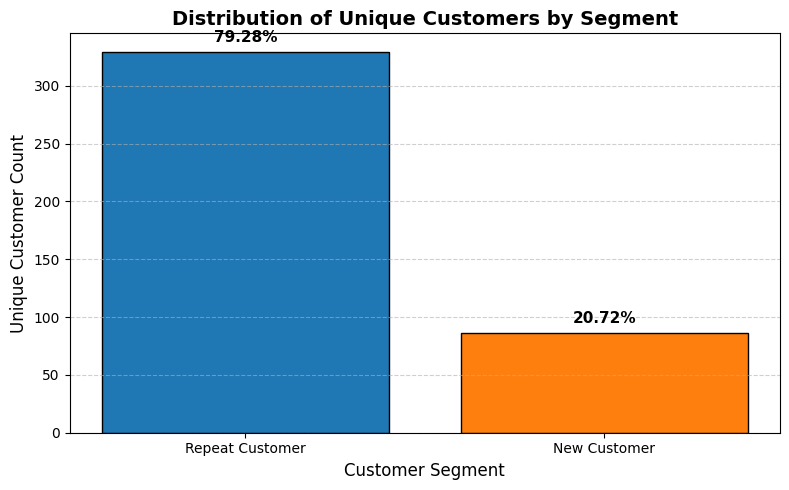

Observation:
The largest customer segment was Repeat Customer.
It represented approximately 79.28% of customers.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Identify whether the segment column is named 'Customer_Segment' or 'Segment'
segment_col = 'Customer_Segment' if 'Customer_Segment' in df.columns else 'Segment'

# 1. Drop duplicate Customer_IDs so each customer is counted only once
unique_customers = df.drop_duplicates(subset=['Customer_ID']).dropna(subset=['Customer_ID', segment_col])

# 2. Count unique customers in each segment
segment_counts = unique_customers[segment_col].value_counts().reset_index()
segment_counts.columns = ['Customer_Segment', 'Customer_Count']

# 3. Calculate percentage of unique customers for each segment
total_customers = segment_counts['Customer_Count'].sum()
segment_counts['Percentage'] = (segment_counts['Customer_Count'] / total_customers) * 100

# 4. Create the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(segment_counts['Customer_Segment'], segment_counts['Customer_Count'], color=['#1f77b4', '#ff7f0e'], edgecolor='black')

# 5. Add percentage labels on top of each bar
for bar, pct in zip(bars, segment_counts['Percentage']):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(segment_counts['Customer_Count']) * 0.02),
             f'{pct:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 6. Titles and axis labels
plt.title('Distribution of Unique Customers by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Unique Customer Count', fontsize=12)

# Grid and styling
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()

# 7. Print the exact observation statement format
top_segment = segment_counts.iloc[0]
print(f"Observation:")
print(f"The largest customer segment was {top_segment['Customer_Segment']}.")
print(f"It represented approximately {top_segment['Percentage']:.2f}% of customers.")

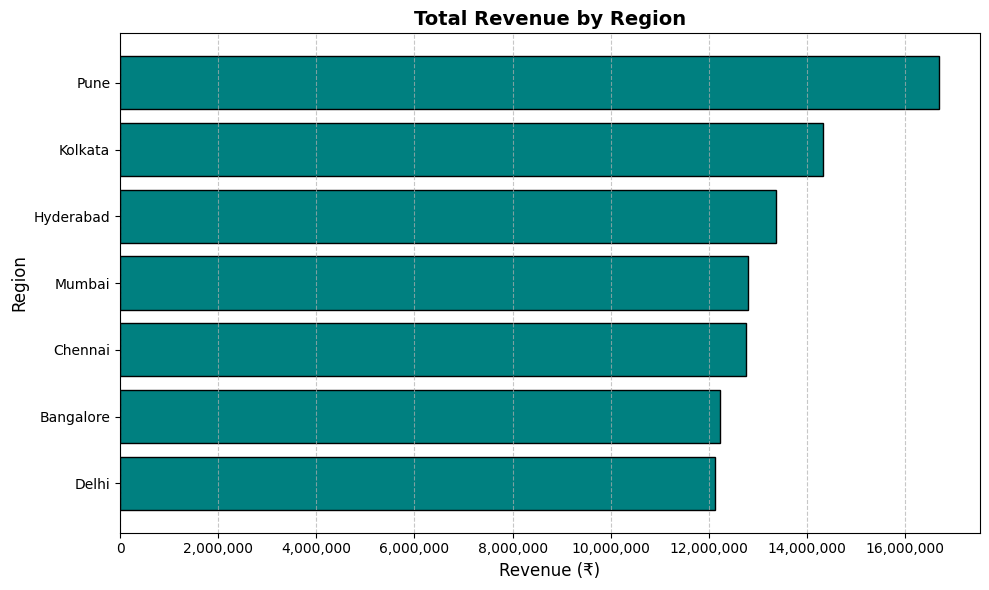

Observation:
The highest revenue-generating region was Pune (₹16,691,688.00).
The lowest revenue-generating region was Delhi (₹12,117,060.00).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean Region column (strips whitespace and standardizes casing)
df['Region_Clean'] = df['Region'].astype(str).str.strip().str.title()

# 2. Clean Revenue column (removes ₹ symbol, commas, spaces) and convert to numeric
df['Revenue_Clean'] = (
    df['Revenue']
    .astype(str)
    .str.replace(r'[^\d.]', '', regex=True)
)
df['Revenue_Clean'] = pd.to_numeric(df['Revenue_Clean'], errors='coerce')

# 3. Group by Region, calculate total Revenue, and sort from highest to lowest
region_revenue = (
    df.groupby('Region_Clean')['Revenue_Clean']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 4. Create the horizontal bar chart
plt.figure(figsize=(10, 6))
# Invert order for barh so the highest revenue appears at the top of the chart
plt.barh(region_revenue['Region_Clean'][::-1], region_revenue['Revenue_Clean'][::-1], color='teal', edgecolor='black')

# 5. Add a clear title
plt.title('Total Revenue by Region', fontsize=14, fontweight='bold')

# 6. Label x-axis Revenue
plt.xlabel('Revenue (₹)', fontsize=12)

# 7. Label y-axis Region
plt.ylabel('Region', fontsize=12)

# Format x-axis numbers with commas for readability
plt.gca().xaxis.set_major_formatter('{x:,.0f}')

# Grid and styling adjustments
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

# Print highest and lowest revenue region observations
highest_region = region_revenue.iloc[0]
lowest_region = region_revenue.iloc[-1]

print("Observation:")
print(f"The highest revenue-generating region was {highest_region['Region_Clean']} (₹{highest_region['Revenue_Clean']:,.2f}).")
print(f"The lowest revenue-generating region was {lowest_region['Region_Clean']} (₹{lowest_region['Revenue_Clean']:,.2f}).")

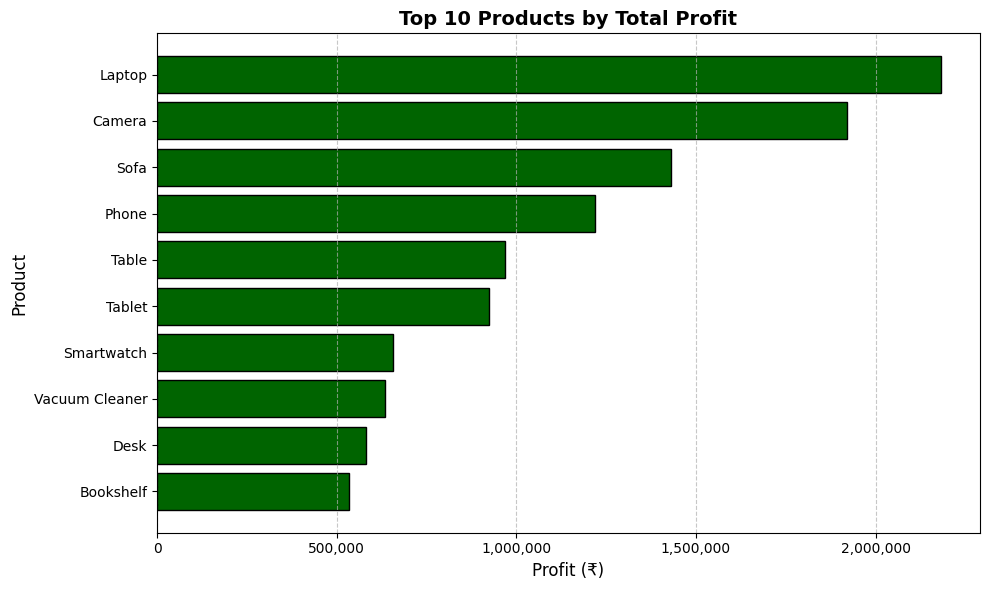

Observation:
The product generating the highest profit was Laptop (₹2,181,549.00).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean Product column (removes extra spaces)
df['Product_Clean'] = df['Product'].astype(str).str.strip()

# 2. Clean Profit column (removes ₹ symbol, commas, spaces) and convert to numeric
df['Profit_Clean'] = (
    df['Profit']
    .astype(str)
    .str.replace(r'[^\d.-]', '', regex=True)
)
df['Profit_Clean'] = pd.to_numeric(df['Profit_Clean'], errors='coerce')

# 3. Group by Product, calculate total Profit, and sort from highest to lowest
product_profit = (
    df.groupby('Product_Clean')['Profit_Clean']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 4. Select the top 10 products
top_10_products = product_profit.head(10)

# 5. Create the horizontal bar chart
plt.figure(figsize=(10, 6))
# Invert order ([::-1]) so the highest profit product is displayed at the top
plt.barh(top_10_products['Product_Clean'][::-1], top_10_products['Profit_Clean'][::-1], color='darkgreen', edgecolor='black')

# 6. Add a clear title
plt.title('Top 10 Products by Total Profit', fontsize=14, fontweight='bold')

# 7. Label x-axis Profit
plt.xlabel('Profit (₹)', fontsize=12)

# 8. Label y-axis Product
plt.ylabel('Product', fontsize=12)

# Format x-axis numbers with commas for readability
plt.gca().xaxis.set_major_formatter('{x:,.0f}')

# Grid and layout adjustments
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

# Print observation summary for top product
top_product = top_10_products.iloc[0]
print("Observation:")
print(f"The product generating the highest profit was {top_product['Product_Clean']} (₹{top_product['Profit_Clean']:,.2f}).")

In [1]:
## m3

SyntaxError: invalid syntax (3082519857.py, line 1)

In [5]:
import pandas as pd

# 1. Base Sheet ID and GID from your Google Sheet link
sheet_id = "1BFhDfOQzLxt0BiS1daLIifn_kBwMv-H6lDTG84k2uII"
gid = "422339371"

# 2. Build the direct CSV export link
export_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# 3. Read data directly into pandas DataFrame
df = pd.read_csv(export_url)

# 4. Display first 5 rows
display(df.head())

# 5. Display column names
print("\n--- COLUMN NAMES ---")
print(df.columns.tolist())

# 6. Display number of rows and columns
rows, columns = df.shape
print(f"\n--- DATASET SHAPE ---")
print(f"Rows: {rows}, Columns: {columns}")

# 7. Display data types
print("\n--- DATA TYPES ---")
print(df.dtypes)

,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit,Order_ID,Order_status,Month,Year,Segment,Order_Value_Category
0,01/06/26,C001,Laptop,Electronics,Delhi,1,"₹65,000.00","₹8,000.00",1001,Completed,June,2026,New Customer,Medium Value
1,03/06/26,C002,Phone,Electronics,Delhi,2,"₹50,000.00","₹6,000.00",1002,Completed,June,2026,Repeat Customer,Medium Value
2,01/02/26,C003,Headphones,Electronics,Mumbai,1,"₹5,000.00","₹1,200.00",1003,Completed,February,2026,Repeat Customer,Low Value
3,05/06/26,C004,Chair,Furniture,Bangalore,3,"₹12,000.00","₹2,500.00",1004,Completed,June,2026,Repeat Customer,Low Value
4,03/07/26,C314,Vacuum Cleaner,Home,Delhi,1,"₹8,506.00","₹1,455.00",1005,Completed,July,2026,Repeat Customer,Low Value



--- COLUMN NAMES ---
['Order_Date', 'Customer_ID', 'Product', 'Category', 'Region', 'Quantity', 'Revenue', 'Profit', 'Order_ID', 'Order_status', 'Month', 'Year', 'Segment', 'Order_Value_Category']

--- DATASET SHAPE ---
Rows: 2000, Columns: 14

--- DATA TYPES ---
Order_Date              object
Customer_ID             object
Product                 object
Category                object
Region                  object
Quantity                 int64
Revenue                 object
Profit                  object
Order_ID                 int64
Order_status            object
Month                   object
Year                    object
Segment                 object
Order_Value_Category    object
dtype: object


In [6]:
# 1. Import pandas library
import pandas as pd

# 2. Convert Order_Date to proper datetime format
# errors='coerce' turns any invalid/corrupted dates into NaT (Not a Time)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Clean Revenue column if it contains text/symbols (like '₹' or commas)
df['Revenue_Clean'] = (
    df['Revenue'].astype(str).str.replace(r'[^\d.]', '', regex=True)
)
df['Revenue_Clean'] = pd.to_numeric(df['Revenue_Clean'], errors='coerce')

# 3. Group by Customer_ID and calculate the required summary metrics
customer_df = (
    df.groupby('Customer_ID')
    .agg(
        Order_Count=('Customer_ID', 'count'),
        Total_Revenue=('Revenue_Clean', 'sum'),
        Avg_Order_Value=('Revenue_Clean', 'mean'),
        First_Purchase=('Order_Date', 'min'),
        Last_Purchase=('Order_Date', 'max'),
    )
    .reset_index()
)

# 4. Display the first 10 rows of the new customer dataset
print('--- FIRST 10 CUSTOMERS ---')
display(customer_df.head(10))

# 5. Display the total number of unique customers
num_customers = customer_df.shape[0]
print(f'\nTotal Number of Customers: {num_customers}')

# 6. Display the column names of the new customer dataset
print('\n--- NEW DATASET COLUMNS ---')
print(customer_df.columns.tolist())

--- FIRST 10 CUSTOMERS ---


/tmp/ipykernel_1547/1346704174.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')


,Customer_ID,Order_Count,Total_Revenue,Avg_Order_Value,First_Purchase,Last_Purchase
0,C001,1,65000.0,65000.000000,2026-01-06,2026-01-06
1,C002,9,256033.0,28448.111111,2026-02-17,2026-12-07
2,C003,3,82737.0,27579.000000,2026-01-02,2026-06-06
3,C004,5,79072.0,15814.400000,2026-03-01,2026-06-07
4,C005,2,49630.0,24815.000000,2026-04-07,2026-12-08
5,C006,3,228080.0,76026.666667,2026-08-19,2026-11-01
6,C007,3,99452.0,33150.666667,2026-04-19,2026-07-29
7,C008,1,76659.0,76659.000000,2026-01-04,2026-01-04
8,C009,3,143415.0,47805.000000,2026-04-25,2026-09-05
9,C010,5,114185.0,22837.000000,2026-01-03,2026-12-07



Total Number of Customers: 415

--- NEW DATASET COLUMNS ---
['Customer_ID', 'Order_Count', 'Total_Revenue', 'Avg_Order_Value', 'First_Purchase', 'Last_Purchase']


In [9]:
# 1. Convert Order_Date to datetime format in your original df
df['Order_Date_DT'] = pd.to_datetime(
    df['Order_Date'], format='%d/%m/%y', errors='coerce'
)

# 2. Find the latest transaction date to use as the reference date
reference_date = df['Order_Date_DT'].max()

# 3. Calculate Recency (days since last purchase)
customer_df['Recency'] = (reference_date - customer_df['Last_Purchase']).dt.days

# 4. Assign Frequency and Monetary
customer_df['Frequency'] = customer_df['Order_Count']
customer_df['Monetary'] = customer_df['Total_Revenue']

# 5. Display the first 10 rows
print("--- CUSTOMER RFM FEATURES (FIRST 10 ROWS) ---")
display(customer_df.head(10))

--- CUSTOMER RFM FEATURES (FIRST 10 ROWS) ---


,Customer_ID,Order_Count,Total_Revenue,Avg_Order_Value,First_Purchase,Last_Purchase,Recency,Frequency,Monetary
0,C001,1,65000.0,65000.000000,2026-01-06,2026-01-06,336,1,65000.0
1,C002,9,256033.0,28448.111111,2026-02-17,2026-12-07,1,9,256033.0
2,C003,3,82737.0,27579.000000,2026-01-02,2026-06-06,185,3,82737.0
3,C004,5,79072.0,15814.400000,2026-03-01,2026-06-07,184,5,79072.0
4,C005,2,49630.0,24815.000000,2026-04-07,2026-12-08,0,2,49630.0
5,C006,3,228080.0,76026.666667,2026-08-19,2026-11-01,37,3,228080.0
6,C007,3,99452.0,33150.666667,2026-04-19,2026-07-29,132,3,99452.0
7,C008,1,76659.0,76659.000000,2026-01-04,2026-01-04,338,1,76659.0
8,C009,3,143415.0,47805.000000,2026-04-25,2026-09-05,94,3,143415.0
9,C010,5,114185.0,22837.000000,2026-01-03,2026-12-07,1,5,114185.0


In [10]:
# 1. Define the churn conditions
# Condition 1: Recency >= 180 days
# Condition 2: Frequency < 5
# Condition 3: Monetary < 100,000
churn_condition = (
    (customer_df['Recency'] >= 180)
    & (customer_df['Frequency'] < 5)
    & (customer_df['Monetary'] < 100000)
)

# 2. Create Churn_Status column (1 for Churned, 0 for Not Churned)
customer_df['Churn_Status'] = 0  # Default all to Not Churned
customer_df.loc[
    churn_condition, 'Churn_Status'
] = 1  # Set to 1 if all conditions match

# 3. Create a human-readable text column (Optional, for easy display)
customer_df['Churn_Label'] = customer_df['Churn_Status'].map(
    {1: 'Churned', 0: 'Not Churned'}
)

# 4. Count and display how many customers are Churned vs Not Churned
print('--- CHURN STATUS COUNT ---')
print(customer_df['Churn_Label'].value_counts())

# 5. Display percentage distribution of Churned vs Not Churned
print('\n--- CHURN PERCENTAGE ---')
print(customer_df['Churn_Label'].value_counts(normalize=True) * 100)

# 6. Display the first 10 rows to verify
display(customer_df.head(10))


--- CHURN STATUS COUNT ---
Churn_Label
Not Churned    340
Churned         75
Name: count, dtype: int64

--- CHURN PERCENTAGE ---
Churn_Label
Not Churned    81.927711
Churned        18.072289
Name: proportion, dtype: float64


,Customer_ID,Order_Count,Total_Revenue,Avg_Order_Value,First_Purchase,Last_Purchase,Recency,Frequency,Monetary,Churn_Status,Churn_Label
0,C001,1,65000.0,65000.000000,2026-01-06,2026-01-06,336,1,65000.0,1,Churned
1,C002,9,256033.0,28448.111111,2026-02-17,2026-12-07,1,9,256033.0,0,Not Churned
2,C003,3,82737.0,27579.000000,2026-01-02,2026-06-06,185,3,82737.0,1,Churned
3,C004,5,79072.0,15814.400000,2026-03-01,2026-06-07,184,5,79072.0,0,Not Churned
4,C005,2,49630.0,24815.000000,2026-04-07,2026-12-08,0,2,49630.0,0,Not Churned
5,C006,3,228080.0,76026.666667,2026-08-19,2026-11-01,37,3,228080.0,0,Not Churned
6,C007,3,99452.0,33150.666667,2026-04-19,2026-07-29,132,3,99452.0,0,Not Churned
7,C008,1,76659.0,76659.000000,2026-01-04,2026-01-04,338,1,76659.0,1,Churned
8,C009,3,143415.0,47805.000000,2026-04-25,2026-09-05,94,3,143415.0,0,Not Churned
9,C010,5,114185.0,22837.000000,2026-01-03,2026-12-07,1,5,114185.0,0,Not Churned


In [ ]:
# Convert Order_Date to datetime
df['Order_Date_DT'] = pd.to_datetime(
    df['Order_Date'], format='%d/%m/%y', errors='coerce'
)

# Define an Observation Cutoff Date (e.g., 6 months before the end date)
cutoff_date = pd.to_datetime('2026-06-01')

# 1. Feature Window (Past transactions used to predict)
features_df = df[df['Order_Date_DT'] <= cutoff_date]

# 2. Churn Window (Future transactions used to label churn)
future_df = df[df['Order_Date_DT'] > cutoff_date]

In [11]:
# Drop rows where Customer_ID is missing
df_clean = df.dropna(subset=['Customer_ID'])

In [12]:
# Use nunique for distinct orders instead of counting rows
Order_Count=('Order_ID', 'nunique')

In [13]:
import pandas as pd

# ---------------------------------------------------------
# STEP 1: Clean Data & Convert Order_Date to Datetime
# ---------------------------------------------------------
# Filter out missing Customer_IDs and clean Revenue string (removes ₹ and commas)
df_clean = df.dropna(subset=['Customer_ID']).copy()
df_clean['Revenue_Clean'] = (
    df_clean['Revenue'].astype(str).str.replace(r'[^\d.]', '', regex=True)
)
df_clean['Revenue_Clean'] = pd.to_numeric(
    df_clean['Revenue_Clean'], errors='coerce'
)

# Convert Order_Date to datetime format
df_clean['Order_Date_DT'] = pd.to_datetime(
    df_clean['Order_Date'], format='%d/%m/%y', errors='coerce'
)

# ---------------------------------------------------------
# STEP 2: Separate Historical & Future Windows
# ---------------------------------------------------------
cutoff_date = pd.to_datetime('2026-03-31')

# Historical Window (Only past transactions used to build features)
history_df = df_clean[df_clean['Order_Date_DT'] <= cutoff_date]

# Future Window (Only future transactions used to determine churn)
future_df = df_clean[df_clean['Order_Date_DT'] > cutoff_date]

# ---------------------------------------------------------
# STEP 3: Create Historical Features (Inputs X)
# ---------------------------------------------------------
customer_features = (
    history_df.groupby('Customer_ID')
    .agg(
        # Recency = Days from customer's last purchase up to the cutoff date
        Last_Purchase_History=('Order_Date_DT', 'max'),
        # Frequency = Count of unique orders made before cutoff
        Frequency=('Order_ID', 'nunique'),
        # Monetary = Total revenue spent before cutoff
        Monetary=('Revenue_Clean', 'sum'),
        # Avg_Order_Value = Average spend per order before cutoff
        Avg_Order_Value=('Revenue_Clean', 'mean'),
    )
    .reset_index()
)

# Calculate Recency relative to the cutoff date
customer_features['Recency'] = (
    cutoff_date - customer_features['Last_Purchase_History']
).dt.days
customer_features.drop(columns=['Last_Purchase_History'], inplace=True)

# ---------------------------------------------------------
# STEP 4: Create Churn Target (Label y)
# ---------------------------------------------------------
# Get unique list of customers who made at least one purchase in the future window
active_future_customers = future_df['Customer_ID'].unique()

# A customer is CHURNED (1) if they did NOT buy anything in the future window; otherwise NOT CHURNED (0)
customer_features['Churn_Status'] = (
    ~customer_features['Customer_ID'].isin(active_future_customers)
).astype(int)

# Human-readable label for inspection
customer_features['Churn_Label'] = customer_features['Churn_Status'].map(
    {1: 'Churned', 0: 'Not Churned'}
)

# ---------------------------------------------------------
# STEP 9: Display Summary & Final Dataset
# ---------------------------------------------------------
print('--- CHURN DISTRIBUTION ---')
print(customer_features['Churn_Label'].value_counts())
print('\n--- PERCENTAGE ---')
print(customer_features['Churn_Label'].value_counts(normalize=True) * 100)

print('\n--- FINAL LEAKAGE-SAFE CUSTOMER DATASET (FIRST 10 ROWS) ---')
display(customer_features.head(10))

--- CHURN DISTRIBUTION ---
Churn_Label
Not Churned    238
Churned         45
Name: count, dtype: int64

--- PERCENTAGE ---
Churn_Label
Not Churned    84.09894
Churned        15.90106
Name: proportion, dtype: float64

--- FINAL LEAKAGE-SAFE CUSTOMER DATASET (FIRST 10 ROWS) ---


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Recency,Churn_Status,Churn_Label
0,C001,1,65000.0,65000.0,84,1,Churned
1,C002,2,55984.0,27992.0,25,0,Not Churned
2,C003,2,73499.0,36749.5,56,0,Not Churned
3,C004,1,48400.0,48400.0,30,0,Not Churned
4,C008,1,76659.0,76659.0,86,1,Churned
5,C010,2,26508.0,13254.0,56,0,Not Churned
6,C012,5,37610.0,7522.0,14,0,Not Churned
7,C013,4,374670.0,93667.5,13,0,Not Churned
8,C014,1,72846.0,72846.0,84,0,Not Churned
9,C015,1,58288.0,58288.0,76,0,Not Churned


--- MISSING VALUES CHECK ---
Recency            0
Frequency          0
Monetary           0
Avg_Order_Value    0
dtype: int64

        MODEL PERFORMANCE METRICS       
Accuracy : 84.21%
Precision: 0.00%
Recall   : 0.00%

--- CONFUSION MATRIX ---

--- CUSTOMER CHURN PREDICTION RESULTS (FIRST 10 TEST CUSTOMERS) ---


,Customer_ID,Actual_Churn_Status,Predicted_Churn_Status,Churn_Probability
0,C465,0,0,0.20
1,C206,0,0,25.80
2,C353,0,0,3.33
3,C401,1,0,9.26
4,C346,0,0,24.40
5,C052,0,0,9.76
6,C156,1,0,29.14
7,C431,0,0,23.18
8,C421,0,0,1.10
9,C185,0,0,21.50


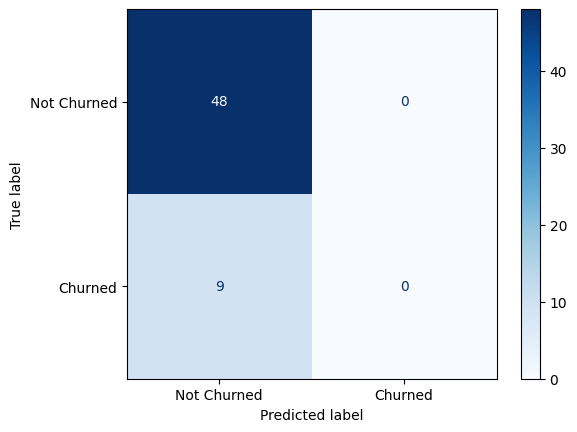

In [14]:
# ==============================================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# STEP 2: SELECT FEATURES (X) AND TARGET (y)
# ==============================================================================
# Define the prediction features
feature_cols = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value']

X = customer_features[feature_cols]
y = customer_features['Churn_Status']

# ==============================================================================
# STEP 3 & 4: CHECK AND HANDLE MISSING VALUES SAFELY
# ==============================================================================
print('--- MISSING VALUES CHECK ---')
print(X.isnull().sum())

# Fill any missing feature values with the median value of that column
X = X.fillna(X.median())

# ==============================================================================
# STEP 5 & 6: SPLIT DATA INTO TRAINING AND TESTING SETS (80% Train, 20% Test)
# ==============================================================================
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    customer_features['Customer_ID'],
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Scale features so large numbers (like Monetary) don't dominate smaller numbers (like Frequency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================================================
# STEP 7: TRAIN LOGISTIC REGRESSION MODEL
# ==============================================================================
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# ==============================================================================
# STEP 8 & 9: GENERATE PREDICTIONS AND PROBABILITIES
# ==============================================================================
# Predict class (0 or 1)
y_pred = model.predict(X_test_scaled)

# Predict churn probability (column 1 represents probability of Churn)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ==============================================================================
# STEP 10, 11, 12 & 13: EVALUATE MODEL PERFORMANCE
# ==============================================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)

print('\n========================================')
print('        MODEL PERFORMANCE METRICS       ')
print('========================================')
print(f'Accuracy : {acc:.2%}')
print(f'Precision: {prec:.2%}')
print(f'Recall   : {rec:.2%}')

# Display Confusion Matrix
print('\n--- CONFUSION MATRIX ---')
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['Not Churned', 'Churned']
)
disp.plot(cmap='Blues')

# ==============================================================================
# STEP 14: CREATE RESULTS TABLE FOR TEST CUSTOMERS
# ==============================================================================
results_df = pd.DataFrame({
    'Customer_ID': id_test.values,
    'Actual_Churn_Status': y_test.values,
    'Predicted_Churn_Status': y_pred,
    'Churn_Probability': (y_prob * 100).round(2),  # Displayed as percentage
})

print('\n--- CUSTOMER CHURN PREDICTION RESULTS (FIRST 10 TEST CUSTOMERS) ---')
display(results_df.head(10))

In [16]:
# 1. Combine test features with model predictions
risk_df = pd.DataFrame({
    'Customer_ID': id_test.values,
    'Recency': X_test['Recency'].values,
    'Frequency': X_test['Frequency'].values,
    'Monetary': X_test['Monetary'].values,
    'Churn_Probability': (y_prob * 100).round(2),
})


# 2. Assign Risk_Level based on rules
def assign_risk_level(prob):
    if prob < 40:
        return 'Low Risk'
    elif prob < 70:
        return 'Medium Risk'
    else:
        return 'High Risk'


risk_df['Risk_Level'] = risk_df['Churn_Probability'].apply(assign_risk_level)

# 3. Sort from highest churn probability to lowest
risk_df_sorted = risk_df.sort_values(
    by='Churn_Probability', ascending=False
).reset_index(drop=True)

# 4. Format Churn_Probability as percentage string for display
risk_df_display = risk_df_sorted.copy()
risk_df_display['Churn_Probability'] = (
    risk_df_display['Churn_Probability'].astype(str) + '%'
)

# 5. Display top 20 highest-risk customers
print('--- TOP 20 HIGHEST-RISK CUSTOMERS ---')
display(risk_df_display.head(20))

--- TOP 20 HIGHEST-RISK CUSTOMERS ---


,Customer_ID,Recency,Frequency,Monetary,Churn_Probability,Risk_Level
0,C216,84,1,15388.0,36.82%,Low Risk
1,C303,87,1,65560.0,35.39%,Low Risk
2,C001,84,1,65000.0,34.56%,Low Risk
3,C115,76,1,36102.0,33.6%,Low Risk
4,C243,64,1,13344.0,31.3%,Low Risk
5,C110,60,1,7572.0,30.48%,Low Risk
6,C112,60,1,24504.0,29.78%,Low Risk
7,C156,54,1,2075.0,29.14%,Low Risk
8,C419,72,1,158925.0,27.4%,Low Risk
9,C206,46,1,36474.0,25.8%,Low Risk


In [17]:
# 1. Import necessary functions
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Select Features and Target
feature_cols = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value']
X = customer_features[feature_cols].fillna(customer_features[feature_cols].median())
y = customer_features['Churn_Status']

# 3. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    customer_features['Customer_ID'],
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train model with class_weight='balanced' to force model to catch churners
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Predict classes and probabilities
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 7. Check Performance Metrics
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred, zero_division=0)
final_recall = recall_score(y_test, y_pred, zero_division=0)

print(f'Accuracy : {final_accuracy:.2%}')
print(f'Precision: {final_precision:.2%}')
print(f'Recall   : {final_recall:.2%}')

Accuracy : 52.63%
Precision: 20.00%
Recall   : 66.67%


In [18]:
# Create main predictions dataframe
all_customer_predictions = pd.DataFrame({
    'Customer_ID': id_test.values,
    'Recency': X_test['Recency'].values,
    'Frequency': X_test['Frequency'].values,
    'Monetary': X_test['Monetary'].values,
    'Actual_Churn': y_test.values,
    'Predicted_Churn': y_pred,
    'Churn_Probability': (y_prob * 100).round(2),
})


# Define Risk Levels
def get_risk_level(prob):
    if prob < 40:
        return 'Low Risk'
    elif prob < 70:
        return 'Medium Risk'
    else:
        return 'High Risk'


all_customer_predictions['Risk_Level'] = all_customer_predictions[
    'Churn_Probability'
].apply(get_risk_level)

# Sort from highest risk to lowest
high_risk_sorted_df = all_customer_predictions.sort_values(
    by='Churn_Probability', ascending=False
).reset_index(drop=True)

# Rename top priority table for display
top_20_retention_list = high_risk_sorted_df.head(20).copy()
top_20_retention_list['Churn_Probability'] = (
    top_20_retention_list['Churn_Probability'].astype(str) + '%'
)

print('--- TOP 20 HIGH RISK CUSTOMERS ---')
display(top_20_retention_list)

--- TOP 20 HIGH RISK CUSTOMERS ---


,Customer_ID,Recency,Frequency,Monetary,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level
0,C216,84,1,15388.0,0,1,74.98%,High Risk
1,C303,87,1,65560.0,0,1,73.53%,High Risk
2,C001,84,1,65000.0,1,1,72.91%,High Risk
3,C115,76,1,36102.0,0,1,72.41%,High Risk
4,C243,64,1,13344.0,0,1,70.73%,High Risk
5,C110,60,1,7572.0,0,1,70.07%,High Risk
6,C112,60,1,24504.0,0,1,69.3%,Medium Risk
7,C156,54,1,2075.0,1,1,68.93%,Medium Risk
8,C419,72,1,158925.0,0,1,65.79%,Medium Risk
9,C206,46,1,36474.0,0,1,65.34%,Medium Risk


In [19]:
# Export results to CSV files
high_risk_sorted_df.to_csv('final_churn_risk_predictions.csv', index=False)
top_20_retention_list.to_csv('top_20_high_risk_customers.csv', index=False)